In [1]:
from datetime import datetime
import os
import glob
from pyhdf.SD import SD, SDC
import re
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature.nightshade import Nightshade
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
from tqdm import tqdm
import numpy as np

Will likely need to consult a ground-track to determine when the satellite passed the terminator. 

In [2]:
clavrx_dir = "/mnt/overcastnas1/LEO_clavrx/JPSS_global/"
clavrx_date_str = "20260402"  # YYYYMMDD
start_time = "0400" # HHmm
end_time = "0420" # HHmm
sat_str = "j01"
clavrx_date = datetime.strptime(clavrx_date_str, "%Y%m%d")
clavrx_julian_str = clavrx_date.strftime("%Y%j")

clavrx_pattern = os.path.join(clavrx_dir, f"{clavrx_julian_str}/*.hdf")
filepath_list = glob.glob(clavrx_pattern)
filepath_list_sat = [s for s in filepath_list if re.search(rf"{sat_str}", s)]
filepath_list_sat.sort()

pattern = re.compile(r"_t(\d{4})\d*")
filepath_list_sat_time = [
    f for f in filepath_list_sat
    if (m := pattern.search(f)) and start_time <= m.group(1) <= end_time
]

In [3]:
example_file=filepath_list[0]

file = SD(example_file, SDC.READ)
print(f"--- HDF contains these datasets: ---")
datasets = file.datasets()
for name in datasets.items():
    print(f"{name[0]}")

--- HDF contains these datasets: ---
scan_line_time
latitude
longitude
solar_zenith_angle
solar_azimuth_angle
sensor_zenith_angle
sensor_azimuth_angle
relative_azimuth_angle
lunar_zenith_angle
lunar_azimuth_angle
cloud_mask
cloud_type
cloud_phase
cld_temp_acha
cld_height_acha
cld_height_base
cld_opd_acha
cld_reff_acha
cld_opd_dcomp
cld_reff_dcomp
cld_cwp_dcomp
cld_opd_nlcomp
cld_reff_nlcomp
cld_cwp_nwp
cld_altitude_acha
cld_base_altitude
refl_lunar_dnb_nom
refl_0_65um_nom
refl_0_86um_nom
refl_1_60um_nom
refl_2_10um_nom
refl_1_38um_nom
temp_3_75um_nom
temp_11_0um_nom
temp_12_0um_nom
ccl_layer_flag
cloud_fraction
ccl_1
ccl_2
ccl_3
ccl_4
ccl_5
land_class
snow_class
surface_elevation
surface_relative_humidity_nwp
rh150_nwp
rhmax_nwp
ice_fraction_nwp
water_equi_snow_depth_nwp
freezing_altitude
freezing_altitude_253
freezing_altitude_268
cld_height_uncer_acha
acha_quality
cld_opd_dcomp_unc
cloud_phase_uncertainty
dcomp_quality
cloud_mask_qf
glint_mask
glint_mask_lunar
glint_zenith_angle
cld_

In [4]:
dataset = 'cloud_mask'

file = SD(example_file, SDC.READ)
print(f"--- {dataset} dataset info ---")
sample = file.select(dataset)
print(f"Name: {sample.info()[0]}")
print(f"Dimensions: {sample.info()[1]}, {sample.dimensions()}")
print(f"Dataset shape: {sample.info()[2]}")
print(f"Data type code: {sample.info()[3]}")
print("--- Attributes")
attrs = sample.attributes()
for key, value in attrs.items():
    print(f"    {key}: {value}")

--- cloud_mask dataset info ---
Name: cloud_mask
Dimensions: 2, {'scan_lines_along_track_direction': 768, 'pixel_elements_along_scan_direction': 3200}
Dataset shape: [768, 3200]
Data type code: 20
--- Attributes
    SCALED: 0
    add_offset: 0.0
    scale_factor: 1.0
    units: none
    standard_name: cloud_mask
    long_name: integer classification of the cloud mask including clear=0, probably-clear=1, probably-cloudy=2, cloudy=3
    coordinates: longitude latitude
    _FillValue: -128
    valid_range: [-127, 127]
    flag_values: [0, 0, 0, 0]
    flag_meanings: clear  probably_clear  probably_cloudy  cloudy


In [5]:
def get_datetime(file):
    match = re.search(r"d(\d{8})_t(\d{7})", file)
    date_str, time_str = match.groups()
    dt = datetime.strptime(date_str + time_str[:6], "%Y%m%d%H%M%S")
    return dt

In [6]:
def opening_clavrx(filepath_list, dataset):
    '''
    :param filepath_list: ['/mnt/overcastnas1/LEO_clavrx/JPSS_global/2026065/clavrx_j01_d20260306_t0401141_e0402386_b42986.level2.hdf', ...]
    :param dataset: 'cloud_mask', 'refl_lunar_dnb_nom'
    '''
    print(f"Opening and stacking {dataset} data from files in list...")
    data_array = []
    for filepath in tqdm(filepath_list, desc="Reading HDF files"):
        try:
            file = SD(filepath, SDC.READ)

            dataset_data = file.select(dataset)
            dataset_array = dataset_data[:]
            data_array.append(dataset_array)

            file.end()
        except ValueError as e:
            print("Error:", e)
            #--- Add 768 (x length of each dataset)
            pad = np.full((768, 3200), np.nan)
            data_array.append(pad)
        except Exception as e:
            print("Error:", e)
            pad = np.full((768, 3200), np.nan)
            data_array.append(pad)

    data_array_combined = np.concatenate(data_array, axis=0)

    return data_array_combined

In [7]:
#--- Much faster after the first one is loaded!
latitudes = opening_clavrx(filepath_list_sat_time, dataset='latitude')
longitudes = opening_clavrx(filepath_list_sat_time, dataset='longitude')
cloud_mask = opening_clavrx(filepath_list_sat_time, dataset='cloud_mask')

Opening and stacking latitude data from files in list...


Reading HDF files: 100%|██████████| 15/15 [00:01<00:00, 13.60it/s]


Opening and stacking longitude data from files in list...


Reading HDF files: 100%|██████████| 15/15 [00:00<00:00, 18.33it/s]


Opening and stacking cloud_mask data from files in list...


Reading HDF files: 100%|██████████| 15/15 [00:00<00:00, 105.97it/s]


In [8]:
#--- Downsampling for faster plotting
fy, fx = 9, 9
latitudes_ds = latitudes[::fy, ::fx]
longitudes_ds = longitudes[::fy, ::fx]
cloud_mask_ds = cloud_mask[::fy, ::fx]

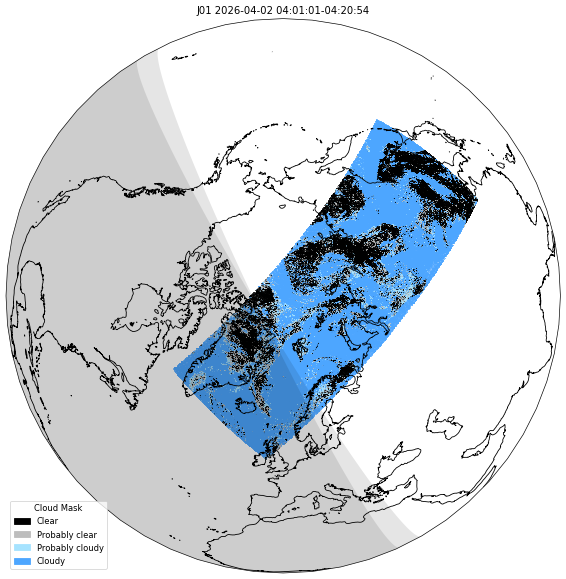

In [9]:
dt_start = get_datetime(filepath_list_sat_time[0])
dt_end = get_datetime(filepath_list_sat_time[-1])

fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': ccrs.Orthographic(central_latitude=90)}, dpi=60)

cloud_colors = [
        "#000000",   # 0 clear
        "#BDBDBD",   # 1 probably clear
        "#A6E3FF",   # 2 probably cloudy
        "#4DA6FF"    # 3 cloudy
    ]
cloud_cmap = ListedColormap(cloud_colors, name="cloud_mask")
bounds = np.arange(-0.5, 4.5, 1)
norm = BoundaryNorm(bounds, cloud_cmap.N)

ax.scatter(longitudes_ds, latitudes_ds, c=cloud_mask_ds, 
           transform=ccrs.PlateCarree(), 
           cmap=cloud_cmap, norm=norm,
           s=0.1, marker='s')

labels = [
    "Clear",
    "Probably clear",
    "Probably cloudy",
    "Cloudy"
]
handles = [
    mpatches.Patch(color=cloud_colors[i], label=labels[i])
    for i in range(4)
]
ax.legend(handles=handles, title="Cloud Mask", loc="lower left")

ax.set_title(f"{sat_str.upper()} {dt_start.strftime("%Y-%m-%d")} {dt_start.strftime("%H:%M:%S")}-{dt_end.strftime("%H:%M:%S")}")
ax.set_global()
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.add_feature(Nightshade(dt_start), alpha=0.1)
ax.add_feature(Nightshade(dt_end), alpha=0.1)

plt.show()
fig.savefig(f"plots/2026_04_29_cloud_mask_terminator_{sat_str}_{dt_start.strftime("%Y_%m_%d_%H")}.png", dpi=300)

In [10]:
dnb_refl = opening_clavrx(filepath_list_sat_time, dataset='refl_lunar_dnb_nom')
dnb_refl_ds = dnb_refl[::fy, ::fx]

Opening and stacking refl_lunar_dnb_nom data from files in list...


Reading HDF files: 100%|██████████| 15/15 [00:00<00:00, 59.77it/s]


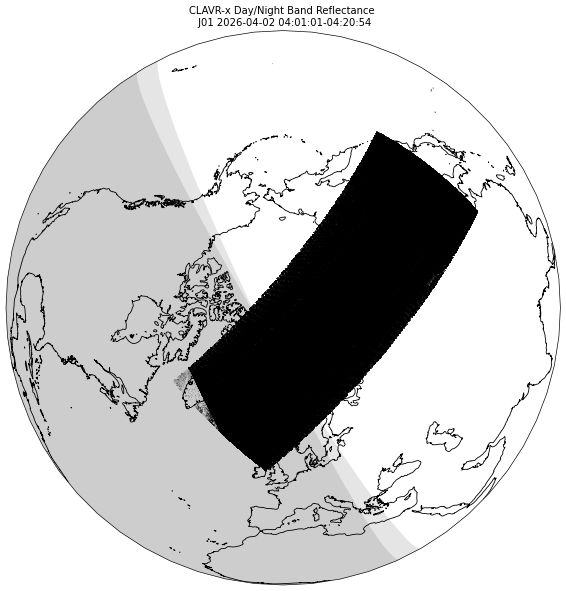

In [11]:
dt_start = get_datetime(filepath_list_sat_time[0])
dt_end = get_datetime(filepath_list_sat_time[-1])

fig,ax=plt.subplots(1, figsize=(12,12),subplot_kw={'projection': ccrs.Orthographic(central_latitude=90)}, dpi=60)

ax.scatter(longitudes_ds, latitudes_ds, c=dnb_refl_ds, 
           transform=ccrs.PlateCarree(), 
           cmap='gray', 
           s=0.1, marker='s', 
           vmin=-32000, vmax=24000)

ax.set_title(f"CLAVR-x Day/Night Band Reflectance \n {sat_str.upper()} {dt_start.strftime("%Y-%m-%d")} {dt_start.strftime("%H:%M:%S")}-{dt_end.strftime("%H:%M:%S")}")
ax.set_global()
ax.coastlines(resolution='50m', color='black', linewidth=1)
ax.add_feature(Nightshade(dt_start), alpha=0.1)
ax.add_feature(Nightshade(dt_end), alpha=0.1)

plt.show()
fig.savefig(f"plots/2026_04_29_dnb_refl_terminator_{sat_str}_{dt_start.strftime("%Y_%m_%d_%H")}.png", dpi=300)